# Test Set Predictions

Loads the trained model and preprocessing state saved by `project.ipynb`, applies the same cleaning pipeline to `test.csv`, and outputs `submission.csv` with probability predictions.

In [2]:
import joblib
import pandas as pd

# load the trained model and the column lists saved from project.ipynb
rf_pruned = joblib.load("rf_pruned.joblib")
state = joblib.load("preprocessing_state.joblib")

zero_cols    = state["zero_cols"]
removed_cols = state["low_var_cols"]
top_features = state["top_features"]

print("model loaded:", rf_pruned)
print(f"zero_cols: {len(zero_cols)}, low_var_cols: {len(removed_cols)}, top_features: {len(top_features)}")

model loaded: RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)
zero_cols: 34, low_var_cols: 63, top_features: 76


In [3]:
# load test data
test_df = pd.read_csv(r"../Dataset/test.csv")

# save IDs before any drops — needed for submission
test_ids = test_df["ID"]

# apply preprocessing in the same order as training
test_df = test_df.drop(columns=["ID"])
test_df = test_df.drop(columns=[c for c in zero_cols    if c in test_df.columns])
test_df = test_df.drop(columns=[c for c in removed_cols if c in test_df.columns])
test_df = test_df[top_features]

print("test shape after preprocessing:", test_df.shape)
print("expected columns:", len(top_features))

test shape after preprocessing: (75818, 76)
expected columns: 76


In [4]:
# predict probability of class 1 (satisfied customer) for each test row
test_proba = rf_pruned.predict_proba(test_df)[:, 1]

print(f"predictions — min: {test_proba.min():.4f}, max: {test_proba.max():.4f}, mean: {test_proba.mean():.4f}")

predictions — min: 0.0000, max: 0.9200, mean: 0.0519


In [5]:
# build and save submission
submission = pd.DataFrame({"ID": test_ids, "TARGET": test_proba})
submission.to_csv("submission.csv", index=False)

print("saved submission.csv")
print(submission.head(10))

saved submission.csv
   ID  TARGET
0   2   0.130
1   5   0.005
2   6   0.000
3   7   0.000
4   9   0.000
5  11   0.165
6  12   0.015
7  15   0.020
8  16   0.015
9  17   0.005


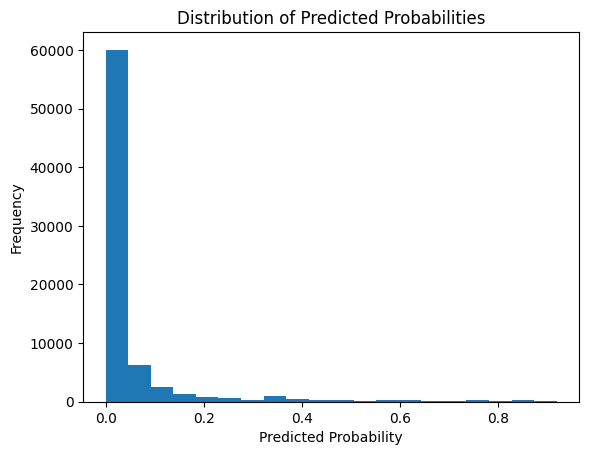

In [ ]:
#distribution of predicted probabilities
import matplotlib.pyplot as plt
plt.hist(test_proba, bins=20)
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.show()

# Thoughts

The distribution of the predicted probabilities show that most customers are 'probably' unsatisfied with the service. This makes sense given the huge class imbalance in the training data. The model is likely picking up on the fact that most customers are unsatisfied and is therefore predicting a high probability of dissatisfaction for most customers in the test set. This is a common issue with imbalanced datasets.